In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import root_mean_squared_error,precision_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# load data
georgia_fars = pd.read_csv("gdot_with_nearest_signal_within_500m.csv")
signal_daily_raw = pd.read_csv("signal_daily_raw.csv")
signal_daily_vh = pd.read_csv("signal_daily_vh.csv")
signal_weekday_avg_raw = pd.read_csv("signal_weekday_avg_raw.csv")
signal_weekday_avg_vh = pd.read_csv("signal_weekday_avg_vh.csv")

In [3]:
# assess number of accidents per year
georgia_fars.groupby("YEAR").size().reset_index(name="n")
# around 1.1k accidents per year
# years from 2016-2023

,YEAR,n
0,2016.0,1097
1,2017.0,1305
2,2018.0,1237
3,2019.0,1197
4,2020.0,1217
5,2021.0,1423
6,2022.0,1324
7,2023.0,1183


In [4]:
# assess number of accident per SignalID
df1 = georgia_fars.groupby("SignalID").size().rename("n")

summary = pd.DataFrame({
    "N": [df1.size],
    "min": [df1.min()],
    "q25": [df1.quantile(0.25)],
    "q50": [df1.median()],
    "q75": [df1.quantile(0.75)],
    "max": [df1.max()]
})

summary
# 2394 signals with median of 3 accidents across all years

,N,min,q25,q50,q75,max
0,2394,1,2.0,3.0,5.0,43


In [5]:
# assess recurrence
df1 = (
    georgia_fars
    .groupby(["YEAR", "SignalID"])
    .size()
    .reset_index(name="n")
)

df2 = (
    df1
    .groupby("SignalID")["n"]
    .size()
    .rename("n")
)

summary = pd.DataFrame({
    "N": [df2.size],
    "min": [df2.min()],
    "q25": [df2.quantile(0.25)],
    "q50": [df2.median()],
    "q75": [df2.quantile(0.75)],
    "max": [df2.max()]
})

summary
# assessing the recurrence of accidents, signals
# have a median of one accident across all years

,N,min,q25,q50,q75,max
0,2394,1,1.0,1.0,2.0,7


In [6]:
# assess if we have same date in different years
df1 = (
    georgia_fars
    .groupby(["YEAR", "SignalID", "MONTH", "DAY"])
    .size()
    .reset_index(name="n")
)

df2 = (
    df1
    .groupby(["SignalID","MONTH", "DAY"])["n"]
    .size()
    .rename("n")
)

summary = pd.DataFrame({
    "N": [df2.size],
    "min": [df2.min()],
    "q25": [df2.quantile(0.25)],
    "q50": [df2.median()],
    "q75": [df2.quantile(0.75)],
    "max": [df2.max()]
})

summary
# there are accidents on the same date on different years
# we would need to take average

,N,min,q25,q50,q75,max
0,3713,1,1.0,1.0,1.0,2


In [7]:
# assess accidents per type of intersection
df1 = georgia_fars.groupby("TYP_INT",dropna=False).size().reset_index(name="n")

df1["prop"] = df1["n"] / df1["n"].sum()

df1
# around 62% of accidents happened at non-intersection
# around 27% of accidents happened at four-way intersections
# around 11% of accidents happened at t-intersections

,TYP_INT,n,prop
0,1.0,6158,0.616849
1,2.0,2681,0.268557
2,3.0,1044,0.104578
3,4.0,49,0.004908
4,6.0,3,0.000301
5,7.0,13,0.001302
6,11.0,5,0.000501
7,NaN,30,0.003005


In [8]:
# assess accidents per pre-crash maneuver
df1 = georgia_fars.groupby("P_CRASH1",dropna=False).size().reset_index(name="n")

df1["prop"] = df1["n"] / df1["n"].sum()

df1

# around 53% of accidents pre-crash manuever was going straight
# around 10% of accidents pre-crash manuever was turning left
# around 0.5% of accidents pre-crash manuever was turning right

,P_CRASH1,n,prop
0,0.0,20,0.002003
1,1.0,5298,0.530702
2,2.0,70,0.007012
3,3.0,6,0.000601
4,4.0,16,0.001603
5,5.0,615,0.061605
6,6.0,103,0.010318
7,7.0,5,0.000501
8,8.0,4,0.000401
9,9.0,8,0.000801


In [9]:
# assess pre-crash manuever at four-way intersection
df1 = georgia_fars[georgia_fars["TYP_INT"]==2]

df1 = df1.groupby("P_CRASH1",dropna=False).size().reset_index(name="n")

df1["prop"] = df1["n"] / df1["n"].sum()

df1
# around 55% of accidents pre-crash manuever was going straight
# around 22% of accidents pre-crash manuever was turning left
# around 0.8% of accidents pre-crash manuever was turning right

,P_CRASH1,n,prop
0,0.0,2,0.000746
1,1.0,1476,0.550541
2,2.0,13,0.004849
3,3.0,2,0.000746
4,4.0,13,0.004849
5,5.0,233,0.086908
6,6.0,7,0.002611
7,10.0,21,0.007833
8,11.0,585,0.218202
9,12.0,4,0.001492


In [10]:
# aggregate georgia fars with date simplest date features
df = georgia_fars[["SignalID", "YEAR", "MONTH", "DAY"]]

daily_counts = df.groupby(["SignalID", "YEAR", "MONTH", "DAY"]).size().reset_index(name="acc_total")

georgia_fars_agg = (
    daily_counts
    .groupby(["SignalID", "MONTH", "DAY"])["acc_total"]
    .mean()
    .reset_index()
)

# use signal daily raw
signal_daily_raw["date"] = pd.to_datetime(signal_daily_raw["date"])

# Select columns and add MONTH and DAY
signal_daily_total = (
    signal_daily_raw[["SignalID", "date", "Vehicle_Vehicle_Total"]]
    .rename(columns={"Vehicle_Vehicle_Total": "total"})
    .assign(
        MONTH=lambda x: x["date"].dt.month,
        DAY=lambda x: x["date"].dt.day
    )
)

In [11]:
# create dataframe with relevant information
df = signal_daily_total.merge(
    georgia_fars_agg,
    on=["SignalID", "MONTH", "DAY"],
    how="left"
)

# impute 0 where acc_total is NA
df["acc_total"] = df["acc_total"].fillna(0)

# assure correct data type
df["SignalID"] = df["SignalID"].astype("category")
df["MONTH"] = df["MONTH"].astype("category")
df["DAY"] = df["DAY"].astype("category")
df["y"] = np.where(df["acc_total"] > 0, 1, 0)
df["y"] = df["y"].astype("category")

# assess how many have accidents
acc_counts = (
    df.assign(acc_bool = df["acc_total"] > 0)
      .groupby("acc_bool")
      .size()
      .reset_index(name="n")
)
acc_counts["prop"] = acc_counts["n"] / acc_counts["n"].sum()
print(acc_counts)
# 0.5% observations have accident records

# assess how many different station have non-zero values
station_counts = (
    df.groupby("SignalID")
      .agg(non_zero = ("acc_total", lambda x: (x>0).sum()))
      .reset_index()
)
station_summary = (
    station_counts.assign(has_value = station_counts["non_zero"] > 0)
                  .groupby("has_value")
                  .size()
                  .reset_index(name="n")
)
print(station_summary)
# 30/50 stations have non-zero values

   acc_bool     n      prop
0     False  9204  0.995027
1      True    46  0.004973
   has_value   n
0      False  20
1       True  30


/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21689/142606798.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("SignalID")


In [12]:
# train/test split
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=123,
    stratify=df["y"] 
)

In [13]:
# linear model

# one-hot encoding
X_train = pd.get_dummies(train_data[["SignalID", "total", "MONTH", "DAY"]], drop_first=True)
y_train = train_data["acc_total"]

X_test = pd.get_dummies(test_data[["SignalID", "total", "MONTH", "DAY"]], drop_first=True)
# align columns in case some categories are missing in test set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test_data["acc_total"]

# model
lm = LinearRegression()
lm.fit(X_train, y_train)

# predictions
train_data["_pred"] = lm.predict(X_train)
test_data["_pred"] = lm.predict(X_test)

# metrics
train_rmse = root_mean_squared_error(y_train, train_data["_pred"])
test_rmse = root_mean_squared_error(y_test, test_data["_pred"])
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.23928883619271288
Test RMSE: 0.1744204616157979


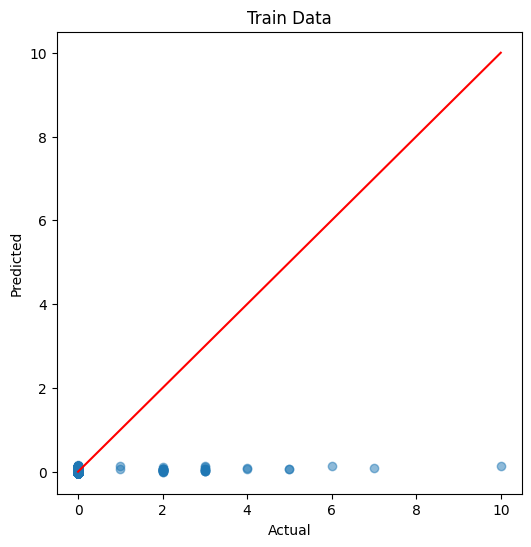

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(train_data["acc_total"], train_data["_pred"], alpha=0.5)
plt.plot([0, train_data["acc_total"].max()], [0, train_data["acc_total"].max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train Data")
plt.show()

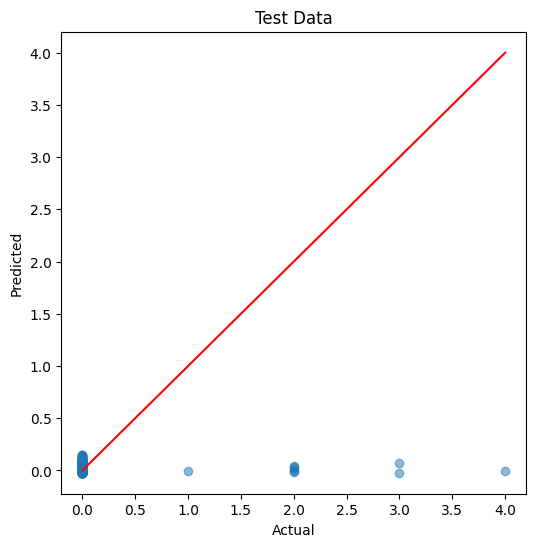

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(test_data["acc_total"], test_data["_pred"], alpha=0.5)
plt.plot([0, test_data["acc_total"].max()], [0, test_data["acc_total"].max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test Data")
plt.show()

In [16]:
# poisson regression 
X_train_sm = sm.add_constant(train_data[["SignalID", "total", "MONTH", "DAY"]])  # add intercept
poi_model = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson())
poi_fit = poi_model.fit()

# predict
train_data["_pred"] = poi_fit.predict(X_train_sm)
X_test_sm = sm.add_constant(test_data[["SignalID", "total", "MONTH", "DAY"]])
test_data["_pred"] = poi_fit.predict(X_test_sm)

# metrics
train_rmse = root_mean_squared_error(y_train, train_data["_pred"])
test_rmse = root_mean_squared_error(y_test, test_data["_pred"])
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.24083397223771702
Test RMSE: 0.17208721461719168


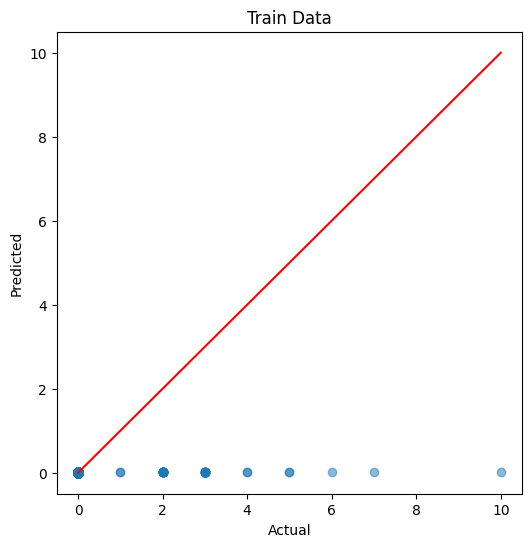

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(train_data["acc_total"], train_data["_pred"], alpha=0.5)
plt.plot([0, train_data["acc_total"].max()], [0, train_data["acc_total"].max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Train Data")
plt.show()

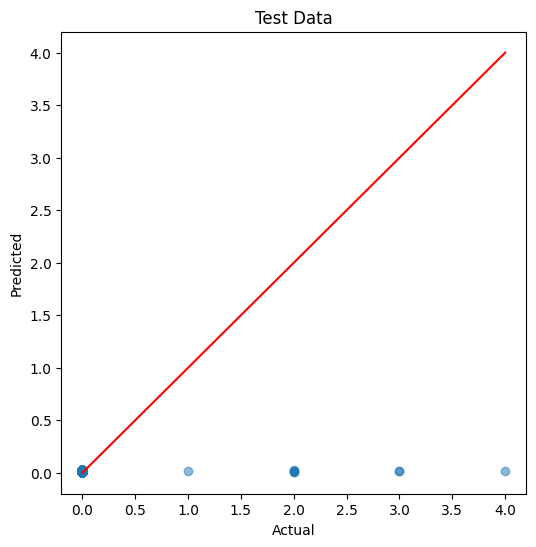

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(test_data["acc_total"], test_data["_pred"], alpha=0.5)
plt.plot([0, test_data["acc_total"].max()], [0, test_data["acc_total"].max()], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test Data")
plt.show()

In [19]:
# logistic regression
X_train = pd.get_dummies(train_data[["SignalID", "total", "MONTH", "DAY"]], drop_first=True)
y_train = train_data["y"]

X_test = pd.get_dummies(test_data[["SignalID", "total", "MONTH", "DAY"]], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test_data["y"]

# oversampling
ros = RandomOverSampler(random_state=123)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# model
log_mod = LogisticRegression(max_iter=1000)
log_mod.fit(X_train_res, y_train_res)

# predictions
train_data["_pred_proba"] = log_mod.predict_proba(X_train)[:, 1]
train_data["_pred_class"] = log_mod.predict(X_train)

test_data["_pred_proba"] = log_mod.predict_proba(X_test)[:, 1]
test_data["_pred_class"] = log_mod.predict(X_test)

# metrics
def evaluate(y_true, y_pred):
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    return pd.Series({"precision": precision, "recall": recall, "f1": f1})

train_metrics = evaluate(train_data["y"], train_data["_pred_class"])
test_metrics = evaluate(test_data["y"], test_data["_pred_class"])

print("Train metrics:\n", train_metrics)
print("Test metrics:\n", test_metrics)

Train metrics:
 precision    0.021400
recall       1.000000
f1           0.041903
dtype: float64
Test metrics:
 precision    0.004890
recall       0.222222
f1           0.009569
dtype: float64


/Users/josemurguiafuentes/Documents/capstone/data/capstone/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# random forest classifier

# model
rf_mod = RandomForestClassifier(random_state=123)
rf_mod.fit(X_train_res, y_train_res)

# predict
train_data["_pred_class"] = rf_mod.predict(X_train)
test_data["_pred_class"] = rf_mod.predict(X_test)

# metrics
train_metrics = evaluate(train_data["y"], train_data["_pred_class"])
test_metrics = evaluate(test_data["y"], test_data["_pred_class"])

print("Train metrics:\n", train_metrics)
print("Test metrics:\n", test_metrics)

Train metrics:
 precision    1.0
recall       1.0
f1           1.0
dtype: float64
Test metrics:
 precision    0.0
recall       0.0
f1           0.0
dtype: float64


/Users/josemurguiafuentes/Documents/capstone/data/capstone/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
# weekly information

# weekly aggregation
georgia_fars_agg_week = (
    georgia_fars[["SignalID", "YEAR", "MONTH", "DAY", "dow"]]
    .groupby(["SignalID", "YEAR", "MONTH", "DAY", "dow"])
    .size()
    .reset_index(name="acc_total")
)

# average over years per SignalID and dow
georgia_fars_agg_week = (
    georgia_fars_agg_week.groupby(["SignalID", "dow"])["acc_total"]
    .mean()
    .reset_index()
)

# total from weekday avg raw
signal_weekly_total = (
    signal_weekday_avg_raw[["SignalID", "dow", "Vehicle_Vehicle_Total"]]
    .rename(columns={"Vehicle_Vehicle_Total": "total"})
)

In [22]:
# create dataframe with relevant information
df = signal_weekly_total.merge(
    georgia_fars_agg_week,
    on=["SignalID", "dow"],
    how="left"
)

# impute 0 where acc_total is NA
df["acc_total"] = df["acc_total"].fillna(0)

# assure correct data type
df["SignalID"] = df["SignalID"].astype("category")
df["dow"] = df["dow"].astype("category")
df["y"] = np.where(df["acc_total"] > 0, 1, 0)
df["y"] = df["y"].astype("category")

# assess how many have accidents
acc_counts = (
    df.assign(acc_bool = df["acc_total"] > 0)
      .groupby("acc_bool")
      .size()
      .reset_index(name="n")
)
acc_counts["prop"] = acc_counts["n"] / acc_counts["n"].sum()
print(acc_counts)
# 21% observations have accident records


# assess how many different station have non-zero values
station_counts = (
    df.groupby("SignalID")
      .agg(non_zero = ("acc_total", lambda x: (x>0).sum()))
      .reset_index()
)
station_summary = (
    station_counts.assign(has_value = station_counts["non_zero"] > 0)
                  .groupby("has_value")
                  .size()
                  .reset_index(name="n")
)
print(station_summary)
# 47/50 stations have non-zero values


   acc_bool    n      prop
0     False  275  0.785714
1      True   75  0.214286
   has_value   n
0      False   3
1       True  47


/var/folders/66/yhbrd2050vz08ncwmjxrnvc40000gn/T/ipykernel_21689/2793285166.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("SignalID")


In [23]:
# train/test split
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=123,
    stratify=df["y"]
)

# one-hot encoding
X_train = pd.get_dummies(train_data[["SignalID", "total", "dow"]], drop_first=True)
y_train = train_data["y"]

X_test = pd.get_dummies(test_data[["SignalID", "total", "dow"]], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test_data["y"]

# oversampling
ros = RandomOverSampler(random_state=123)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# logistic regression
lasso_log_mod = LogisticRegression(
    penalty="l1",        # Lasso
    solver="saga",       # required for L1
    max_iter=5000,
    C=1.0,               # inverse of regularization strength
    random_state=123
)
lasso_log_mod.fit(X_train_res, y_train_res)

# predictions
train_data["_pred_class"] = lasso_log_mod.predict(X_train)
train_data["_pred_proba"] = lasso_log_mod.predict_proba(X_train)[:, 1]

test_data["_pred_class"] = lasso_log_mod.predict(X_test)
test_data["_pred_proba"] = lasso_log_mod.predict_proba(X_test)[:, 1]

# metrics
train_metrics = evaluate(train_data["y"], train_data["_pred_class"])
test_metrics = evaluate(test_data["y"], test_data["_pred_class"])

print("Train metrics:\n", train_metrics)
print("Test metrics:\n", test_metrics)

Train metrics:
 precision    0.282353
recall       0.400000
f1           0.331034
dtype: float64
Test metrics:
 precision    0.277778
recall       0.333333
f1           0.303030
dtype: float64


/Users/josemurguiafuentes/Documents/capstone/data/capstone/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [24]:
# frequency count at signal level

# initial grouping: count accidents
tmp = (
    georgia_fars[["SignalID", "YEAR", "MONTH", "DAY", "TYP_INT", "P_CRASH1"]]
    .groupby(["SignalID", "YEAR", "MONTH", "DAY", "TYP_INT", "P_CRASH1"], dropna=False)
    .size()
    .reset_index(name="acc_total")
)

# second grouping: mean accident count
tmp2 = (
    tmp.groupby(["SignalID", "MONTH", "DAY", "TYP_INT", "P_CRASH1"], dropna=False)
       .agg(acc_total=("acc_total", "mean"))
       .reset_index()
)

# indicators for maneuver types
tmp2["LEFT_ACC"] = (tmp2["P_CRASH1"] == 11).astype(int)
tmp2["RIGHT_ACC"] = (tmp2["P_CRASH1"] == 12).astype(int)
tmp2["STRAIGHT_ACC"] = (tmp2["P_CRASH1"] == 1).astype(int)
tmp2["M_NA_ACC"] = tmp2["P_CRASH1"].isna().astype(int)

# OTHER_ACC = 1 if none of the above matched
tmp2["OTHER_ACC"] = np.where(
    tmp2["LEFT_ACC"] + tmp2["RIGHT_ACC"] + tmp2["STRAIGHT_ACC"] + tmp2["M_NA_ACC"] > 0,
    0,
    1
)

# summarize by intersection/day
georgia_fars_manuever = (
    tmp2.groupby(["SignalID", "MONTH", "DAY", "TYP_INT"], dropna=False)
        .agg({
            "LEFT_ACC": "sum",
            "RIGHT_ACC": "sum",
            "STRAIGHT_ACC": "sum",
            "M_NA_ACC": "sum",
            "OTHER_ACC": "sum"
        })
        .reset_index()
)

georgia_fars_manuever["TOTAL_ACC"] = (
    georgia_fars_manuever[["LEFT_ACC", "RIGHT_ACC", "STRAIGHT_ACC", "M_NA_ACC", "OTHER_ACC"]].sum(axis=1)
)

In [25]:
signal_daily_manuever = signal_daily_raw.copy()

# LEFT/R/T = sum of selected columns
signal_daily_manuever["LEFT"] = signal_daily_manuever.filter(regex="_L$").sum(axis=1)
signal_daily_manuever["RIGHT"] = signal_daily_manuever.filter(regex="_R$").sum(axis=1)
signal_daily_manuever["STRAIGHT"] = signal_daily_manuever.filter(regex="_T$").sum(axis=1)

signal_daily_manuever["MONTH"] = signal_daily_manuever["date"].dt.month
signal_daily_manuever["DAY"] = signal_daily_manuever["date"].dt.day

signal_daily_manuever = signal_daily_manuever[
    ["SignalID", "MONTH", "DAY", "LEFT", "RIGHT", "STRAIGHT"]
]

In [26]:
df_manuever = georgia_fars_manuever.merge(
    signal_daily_manuever,
    on=["SignalID", "MONTH", "DAY"],
    how="inner"
)

In [27]:
df_manuever.shape

(46, 13)

In [28]:
df_left_vs_straight = (
    df_manuever
    .query("TYP_INT == 2 and LEFT_ACC > 0 and STRAIGHT_ACC > 0")
    .assign(ratio=lambda x: (x["LEFT_ACC"] / x["LEFT"]) / (x["STRAIGHT_ACC"] / x["STRAIGHT"]))
)

df_left_vs_straight

,SignalID,MONTH,DAY,TYP_INT,LEFT_ACC,RIGHT_ACC,STRAIGHT_ACC,M_NA_ACC,OTHER_ACC,TOTAL_ACC,LEFT,RIGHT,STRAIGHT,ratio
4,1896,8,27,2.0,1,0,1,0,0,2,4434.0,0.0,38837.0,8.758908
7,5045,5,25,2.0,1,0,1,0,0,2,886.0,0.0,5865.0,6.619639
41,1351385,5,11,2.0,1,0,1,0,0,2,1514.0,0.0,16654.0,11.000000


In [29]:
df_left_vs_right = (
    df_manuever
    .query("TYP_INT == 2 and LEFT_ACC > 0 and RIGHT_ACC > 0")
    .assign(ratio=lambda x: (x["LEFT_ACC"] / x["LEFT"]) / (x["RIGHT_ACC"] / x["RIGHT"]))
)

df_left_vs_right

,SignalID,MONTH,DAY,TYP_INT,LEFT_ACC,RIGHT_ACC,STRAIGHT_ACC,M_NA_ACC,OTHER_ACC,TOTAL_ACC,LEFT,RIGHT,STRAIGHT,ratio
